In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.plotting import parallel_coordinates
from matplotlib.gridspec import GridSpec

In [50]:
df = pd.read_csv("data/csv/cicddos_2019.csv")  # Thay "data.csv" bằng file của bạn

In [46]:
# selected_columns = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
#                     'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
#                     'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
#                     'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
#                     'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
#                     'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
#                     'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
#                     'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
#                     'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
#                     'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
#                     'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']
# df = df[selected_columns]


In [51]:
X = df.drop(columns=['Label'])
# X = X.dropna()
# X = X.fillna(X.mean())
# X.replace([np.inf, -np.inf], np.nan, inplace=True)  # Chuyển inf thành NaN
# X = X.dropna()  # Xóa dòng chứa NaN


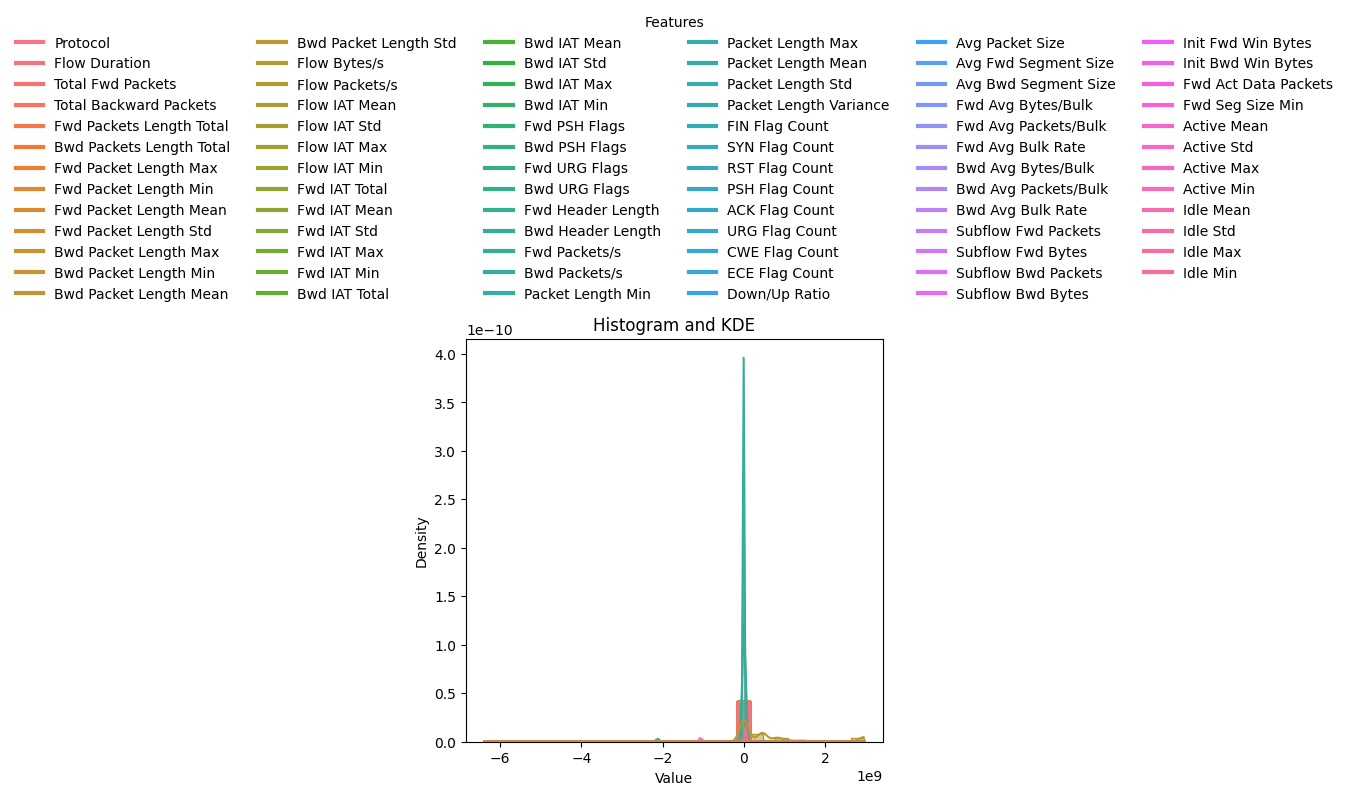

In [ ]:
# Tạo layout 2 hàng với GridSpec
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 1, height_ratios=[1, 4])  # Hàng 1 (legend) chiếm 1 phần, hàng 2 (biểu đồ) chiếm 4 phần

# Hàng 1: Hiển thị legend
ax_legend = fig.add_subplot(gs[0])
ax_legend.axis('off')  # Ẩn trục

# Tạo dummy lines để hiển thị legend
colors = sns.color_palette("husl", n_colors=len(X.columns))
lines = [plt.Line2D([0], [0], color=c, linewidth=3) for c in colors]

# Hiển thị legend với 2 cột và căn giữa
ax_legend.legend(
    lines, X.columns,
    loc='center',
    ncol=5,  # Số cột trong legend (điều chỉnh tùy số lượng đặc trưng)
    title="Features",
    frameon=False
)

# Hàng 2: Vẽ biểu đồ
ax_plot = fig.add_subplot(gs[1])
sns.histplot(X, kde=True, bins=30, stat='density', element='step', alpha=0.5, ax=ax_plot)

ax_plot.legend_.remove()

# Tùy chỉnh biểu đồ
ax_plot.set_title('Histogram and KDE')
ax_plot.set_xlabel('Value')
ax_plot.set_ylabel('Density')

plt.tight_layout()
plt.show()